<a href="https://colab.research.google.com/github/melisabozuklu-lang/Melisa-BOZUKLU-lab2/blob/main/Untitled0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

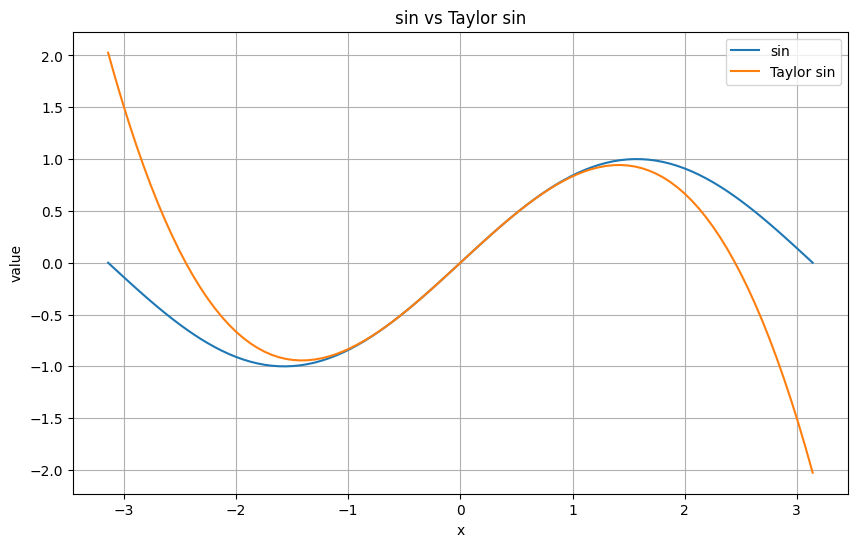

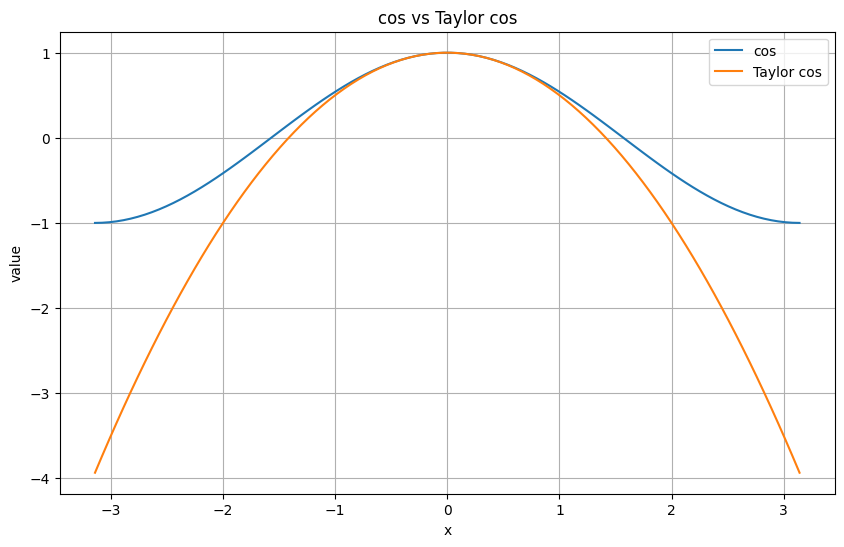

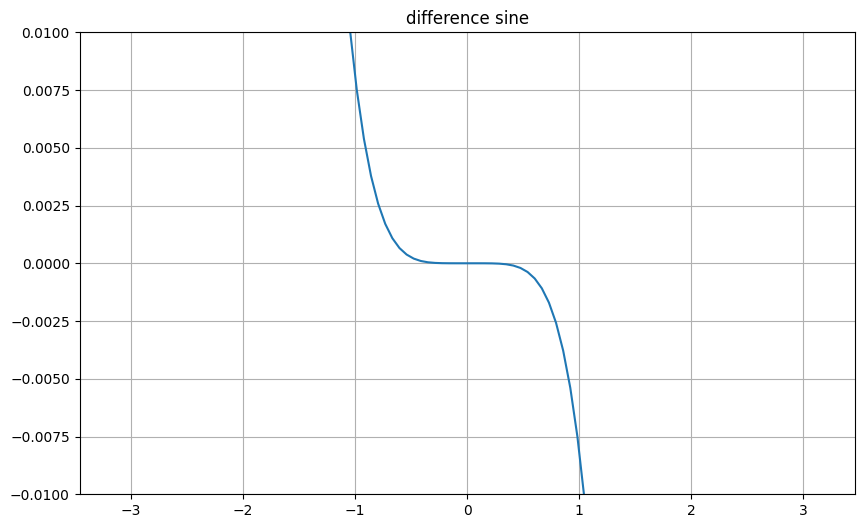

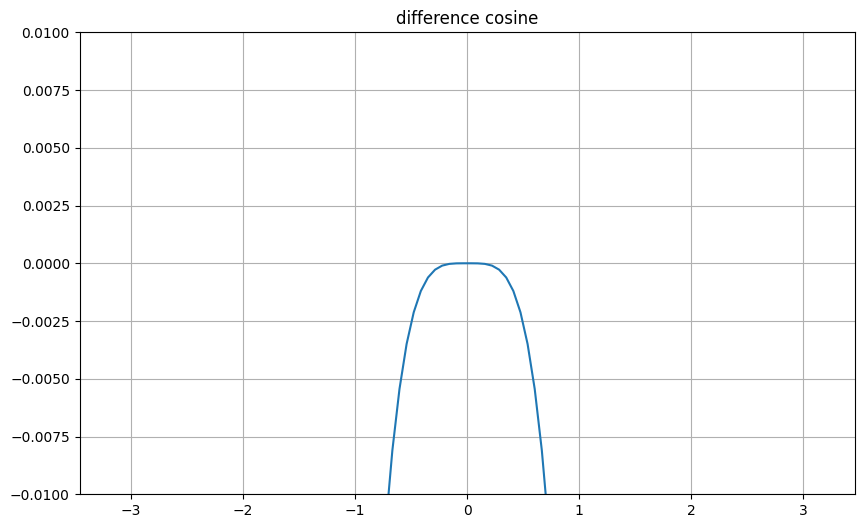

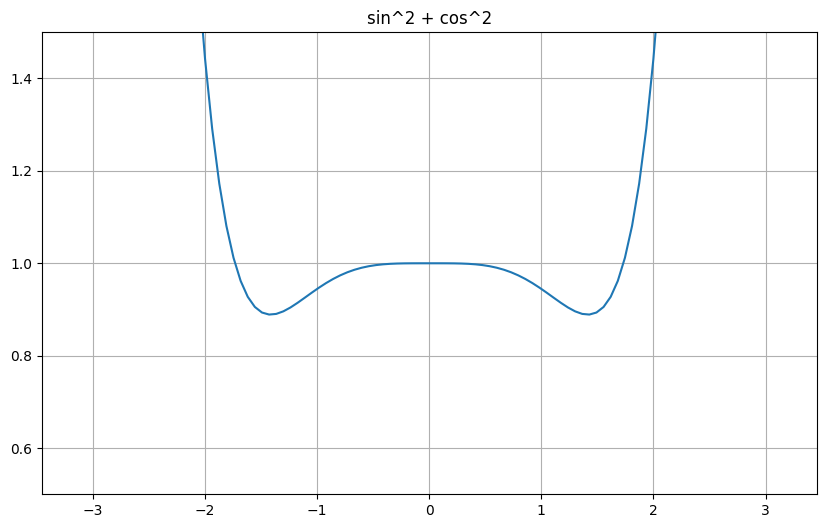

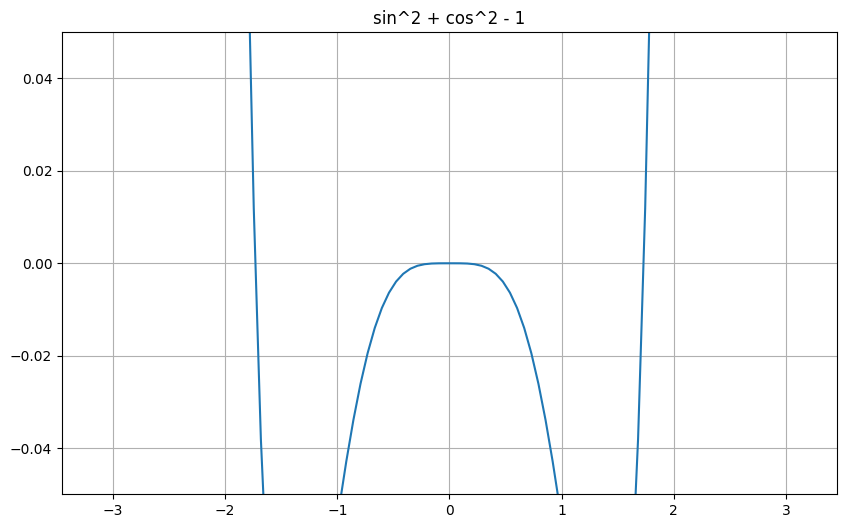

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Taylor approximations
def sin_series(x, terms):
    total = 0
    for k in range(terms):
        total += ((-1)**k * x**(2*k + 1)) / math.factorial(2*k + 1)
    return total

def cos_series(x, terms):
    total = 0
    for k in range(terms):
        total += ((-1)**k * x**(2*k)) / math.factorial(2*k)
    return total


# plotting helpers
def draw_compare(real_func, approx_func, title1, title2, terms=5):
    x = np.linspace(-np.pi, np.pi, 100)

    plt.figure(figsize=(10,6))
    plt.plot(x, real_func(x), label=title1)
    plt.plot(x, approx_func(x, terms), label=title2)

    plt.title(f"{title1} vs {title2}")
    plt.xlabel("x")
    plt.ylabel("value")
    plt.grid(True)
    plt.legend()
    plt.show()


def draw_single(func, title, terms=5, scale=0):
    x = np.linspace(-np.pi, np.pi, 100)

    plt.figure(figsize=(10,6))
    plt.plot(x, func(x, terms))

    plt.title(title)
    plt.grid(True)

    if scale == 1:
        plt.ylim(-0.01,0.01)
    elif scale == 2:
        plt.ylim(-0.05,0.05)
    else:
        plt.ylim(0.5,1.5)

    plt.show()


# differences
def sin_error(x, n):
    return sin_series(x,n) - np.sin(x)

def cos_error(x, n):
    return cos_series(x,n) - np.cos(x)

def identity(x, n):
    return sin_series(x,n)**2 + cos_series(x,n)**2

def identity_error(x, n):
    return sin_series(x,n)**2 + cos_series(x,n)**2 - 1


# main
draw_compare(np.sin, sin_series, "sin", "Taylor sin", terms=2)
draw_compare(np.cos, cos_series, "cos", "Taylor cos", terms=2)

draw_single(sin_error, "difference sine", terms=2, scale=1)
draw_single(cos_error, "difference cosine", terms=2, scale=1)

draw_single(identity, "sin^2 + cos^2", terms=2)
draw_single(identity_error, "sin^2 + cos^2 - 1", terms=2, scale=2)